**Subject Name :** **Introduction to Data Science Lab.** <br>
**Subject Code :** **MCAD191A** <br>
**Topic :** **Binning** <br>
**Department of Computer Applications** <br>
**Seacom Skills University**

**Binning**

<p>Binning or discretization is a data preprocessing technique in Data Mining and Machine Learning where continuous numerical values are converted into small intervals called bins.</p>

**Types of Binning** <br>

1.   Equal Width Binning
2.   Equal Depth Binning (Equal Frequency / Quantile Binning)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.DataFrame({"value": [5, 7, 15, 18, 23, 29, 35, 40, 47, 50]})
print(data)

   value
0      5
1      7
2     15
3     18
4     23
5     29
6     35
7     40
8     47
9     50


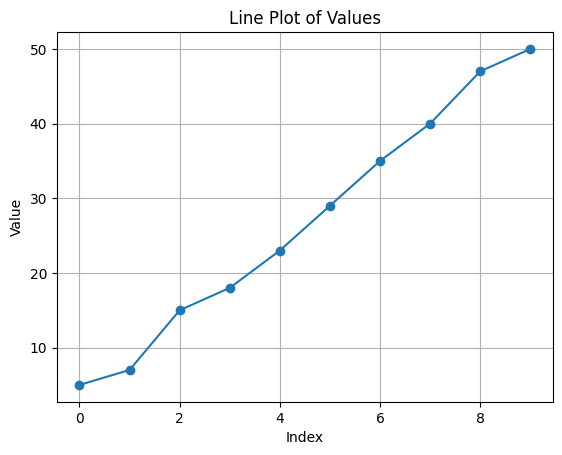

In [3]:
#Line Plot
plt.figure()
plt.plot(data.index, data["value"], marker='o')
plt.title("Line Plot of Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

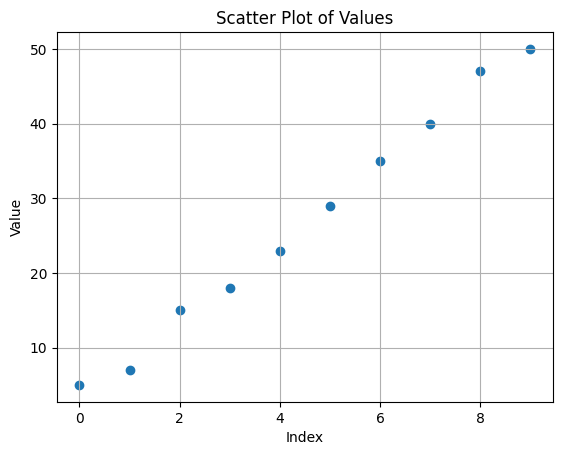

In [4]:
#Scatter Plot
plt.figure()
plt.scatter(data.index, data["value"])
plt.title("Scatter Plot of Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

**1. Equal Width Binning**<br>
Each bin has an equal width, determined by dividing the range of the data into n intervals.

In [5]:
#Equal Width Binning (with 4 bins)
data["equal_width_bin"] = pd.cut(data["value"], bins=4)
print(data)

   value equal_width_bin
0      5  (4.955, 16.25]
1      7  (4.955, 16.25]
2     15  (4.955, 16.25]
3     18   (16.25, 27.5]
4     23   (16.25, 27.5]
5     29   (27.5, 38.75]
6     35   (27.5, 38.75]
7     40   (38.75, 50.0]
8     47   (38.75, 50.0]
9     50   (38.75, 50.0]


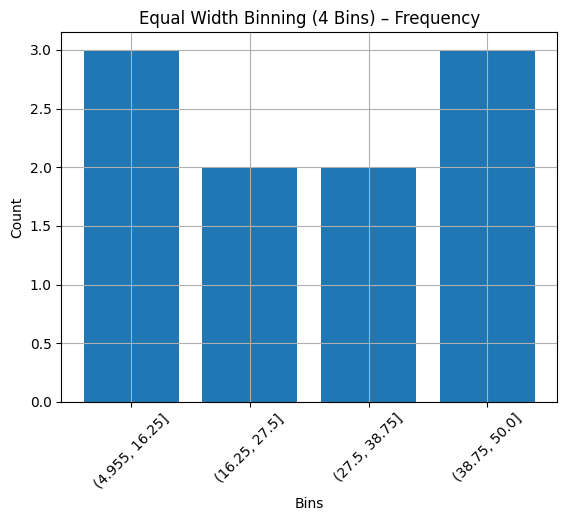

In [6]:
#Bar Chart
bin_counts = data["equal_width_bin"].value_counts().sort_index()

plt.figure()
plt.bar(bin_counts.index.astype(str), bin_counts.values)
plt.title("Equal Width Binning (4 Bins) – Frequency")
plt.xlabel("Bins")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

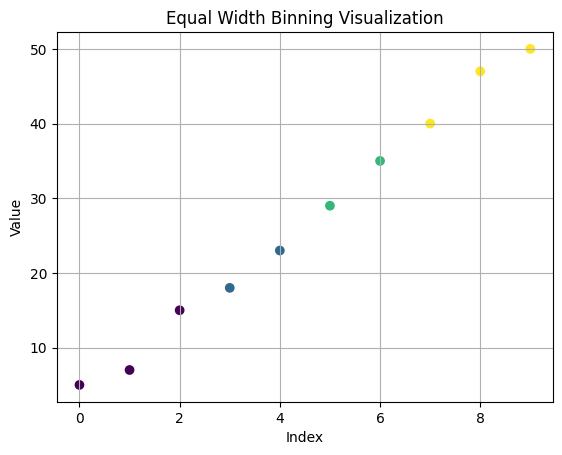

In [7]:
#Scatter Plot
plt.figure()
plt.scatter(data.index, data["value"], c=data["equal_width_bin"].cat.codes)
plt.title("Equal Width Binning Visualization")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

**2. Equal Depth Binning**<br>
Each bin contains approximately the same number of data points.

In [8]:
#Equal Depth Binning into 4 bins
data["equal_depth_bin"] = pd.qcut(data["value"], q=4)
print(data)

   value equal_width_bin equal_depth_bin
0      5  (4.955, 16.25]  (4.999, 15.75]
1      7  (4.955, 16.25]  (4.999, 15.75]
2     15  (4.955, 16.25]  (4.999, 15.75]
3     18   (16.25, 27.5]   (15.75, 26.0]
4     23   (16.25, 27.5]   (15.75, 26.0]
5     29   (27.5, 38.75]   (26.0, 38.75]
6     35   (27.5, 38.75]   (26.0, 38.75]
7     40   (38.75, 50.0]   (38.75, 50.0]
8     47   (38.75, 50.0]   (38.75, 50.0]
9     50   (38.75, 50.0]   (38.75, 50.0]


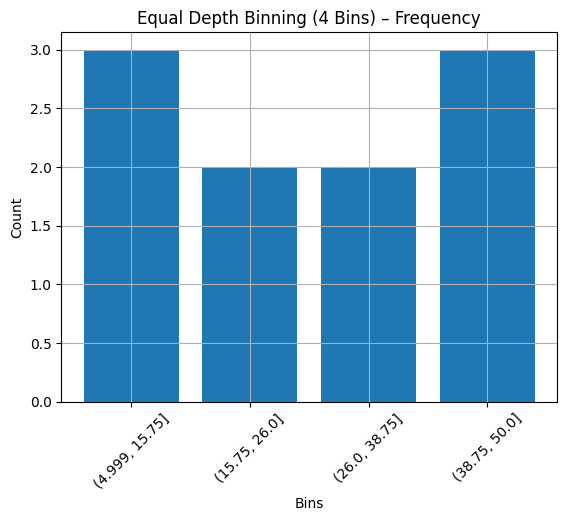

In [9]:
#Bar Chart
bin_counts = data["equal_depth_bin"].value_counts().sort_index()

plt.figure()
plt.bar(bin_counts.index.astype(str), bin_counts.values)
plt.title("Equal Depth Binning (4 Bins) – Frequency")
plt.xlabel("Bins")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

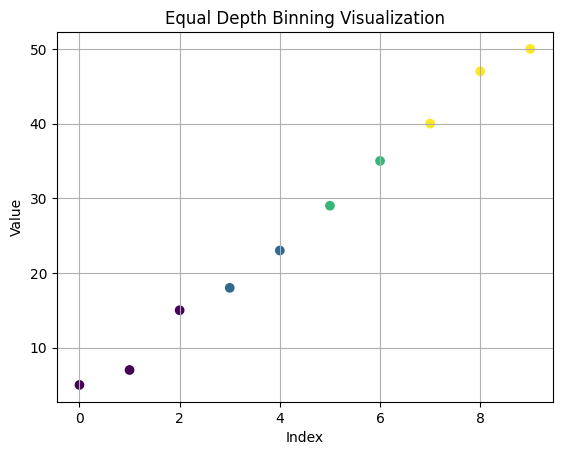

In [10]:
#Scatter Plot
plt.figure()
plt.scatter(data.index, data["value"], c=data["equal_depth_bin"].cat.codes)
plt.title("Equal Depth Binning Visualization")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

**Observation from Graphs**

Equal Width Binning: bin ranges are equal, frequencies may vary.

Equal Depth Binning: frequencies are (almost) equal, ranges vary.

Since, we have only 10 values and 4 bins, each bin contains 2–3 values.

**Comparison of Equal Width vs Equal Depth Binning**

**Observation from Graphs**

Equal Width: Some bins have more values, some fewer.

Equal Depth: Each bin contains almost the same number of data points.

In [11]:
#Quantile Binning using quartiles
data["quantile_bin"] = pd.qcut(data["value"], q=[0, 0.25, 0.50, 0.75, 1.0])
print(data)

   value equal_width_bin equal_depth_bin    quantile_bin
0      5  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]
1      7  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]
2     15  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]
3     18   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]
4     23   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]
5     29   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]
6     35   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]
7     40   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]
8     47   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]
9     50   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]


/tmp/ipython-input-128645713.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data["smooth_mean"] = bins.map(data.groupby(bins)["value"].mean())


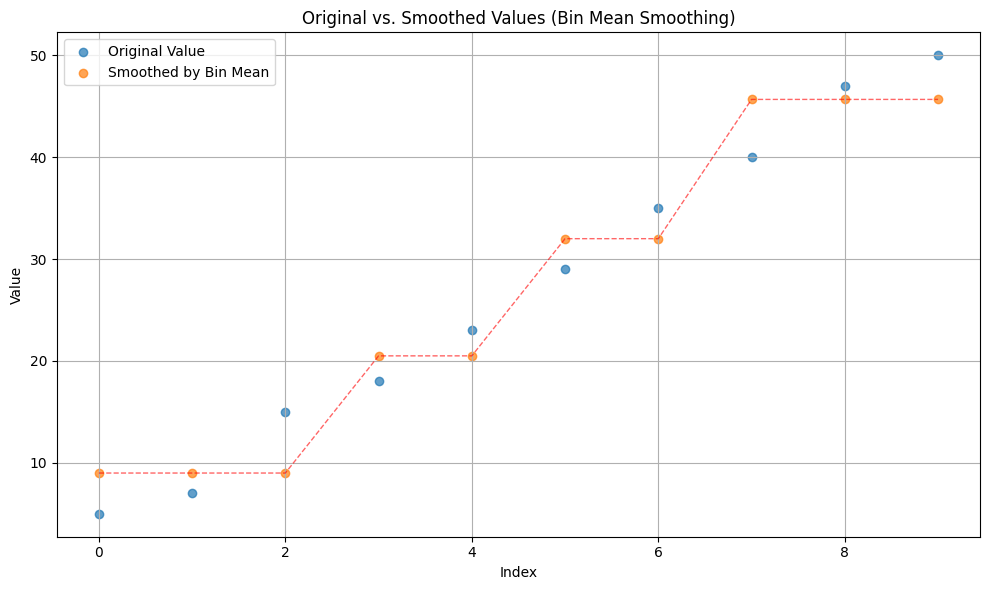

In [12]:
bins = pd.qcut(data["value"], q=4)
data["smooth_mean"] = bins.map(data.groupby(bins)["value"].mean())

plt.figure(figsize=(10, 6))
plt.scatter(data.index, data["value"], label="Original Value", alpha=0.7)
plt.scatter(data.index, data["smooth_mean"], label="Smoothed by Bin Mean", alpha=0.7)
plt.plot(data.index, data["smooth_mean"], color="red", linestyle="--", linewidth=1, alpha=0.6)
plt.title("Original vs. Smoothed Values (Bin Mean Smoothing)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Importance of Binning**<br><br>
**Data Smoothing:** <br>
Binning helps reduce the impact of minor observation variations, effectively smoothing the data.<br>
**Outlier Mitigation:** <br>
It reduces the influence of outliers by grouping values into bins.<br>
**Improved Analysis:** <br>
Discretizing continuous data simplifies data analysis and enables better visualization.<br>
**Feature Engineering:** <br>
Binned variables can be more intuitive and useful in predictive modeling.

**Data Smoothing using Binning**

**a. Smoothing by Bin Mean**<br>
Replace all values in a bin with the mean of that bin.

In [13]:
#Create bins (equal depth)
bins = pd.qcut(data["value"], q=4)

#Calculate mean for each bin & replace values
data["smooth_mean"] = bins.map(data.groupby(bins)["value"].mean())
print(data)

   value equal_width_bin equal_depth_bin    quantile_bin smooth_mean
0      5  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000
1      7  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000
2     15  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000
3     18   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]   20.500000
4     23   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]   20.500000
5     29   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]   32.000000
6     35   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]   32.000000
7     40   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667
8     47   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667
9     50   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667


/tmp/ipython-input-2999501964.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data["smooth_mean"] = bins.map(data.groupby(bins)["value"].mean())


**b. Smoothing by Bin Median** <br>
Replace all values with the median of that bin.

In [14]:
data["smooth_median"] = bins.map(data.groupby(bins)["value"].median())
print(data)

   value equal_width_bin equal_depth_bin    quantile_bin smooth_mean  \
0      5  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000   
1      7  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000   
2     15  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000   
3     18   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]   20.500000   
4     23   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]   20.500000   
5     29   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]   32.000000   
6     35   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]   32.000000   
7     40   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667   
8     47   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667   
9     50   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667   

  smooth_median  
0           7.0  
1           7.0  
2           7.0  
3          20.5  
4          20.5  
5          32.0  
6          32.0  
7          47.0  
8          47.0  
9          47.0  


/tmp/ipython-input-3821150158.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data["smooth_median"] = bins.map(data.groupby(bins)["value"].median())


**c. Smoothing by Bin Boundary**<br>
Replace each value with the closest boundary of its bin:
*  Lower bound
*  Upper bound

In [15]:
#Bin boundaries
bin_intervals = bins.cat.categories

def boundary_smooth(val, bins, intervals):
    # Find bin index
    idx = bins.cat.categories.get_indexer([bins[value_index]])[0]

for i in range(len(data)):
    bin_bounds = bin_intervals[bins.cat.codes[i]]
    lower, upper = bin_bounds.left, bin_bounds.right
    val = data.loc[i, "value"]
    # Replace with closest bound
    data.loc[i, "smooth_boundary"] = lower if abs(val - lower) < abs(val - upper) else upper

print(data)

   value equal_width_bin equal_depth_bin    quantile_bin smooth_mean  \
0      5  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000   
1      7  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000   
2     15  (4.955, 16.25]  (4.999, 15.75]  (4.999, 15.75]    9.000000   
3     18   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]   20.500000   
4     23   (16.25, 27.5]   (15.75, 26.0]   (15.75, 26.0]   20.500000   
5     29   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]   32.000000   
6     35   (27.5, 38.75]   (26.0, 38.75]   (26.0, 38.75]   32.000000   
7     40   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667   
8     47   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667   
9     50   (38.75, 50.0]   (38.75, 50.0]   (38.75, 50.0]   45.666667   

  smooth_median  smooth_boundary  
0           7.0            4.999  
1           7.0            4.999  
2           7.0           15.750  
3          20.5           15.750  
4          20.5           26.000

**Binning on Titanic Dataset**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("/content/titanic.csv")

In [18]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [20]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Equal Width Binning on Age**

In [21]:
#4 equal interval bins
data["age_equal_width"] = pd.cut(data["Age"], bins=4)
data[["Age", "age_equal_width"]].head()

,Age,age_equal_width
0,22.0,"(20.315, 40.21]"
1,38.0,"(20.315, 40.21]"
2,26.0,"(20.315, 40.21]"
3,35.0,"(20.315, 40.21]"
4,35.0,"(20.315, 40.21]"


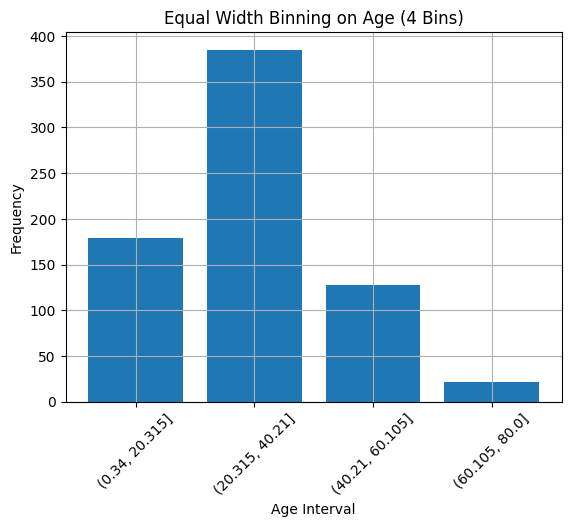

In [22]:
#Bar Chart
#Count values in each age bin
age_bin_counts = data["age_equal_width"].value_counts().sort_index()

plt.figure()
plt.bar(age_bin_counts.index.astype(str), age_bin_counts.values)
plt.title("Equal Width Binning on Age (4 Bins)")
plt.xlabel("Age Interval")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

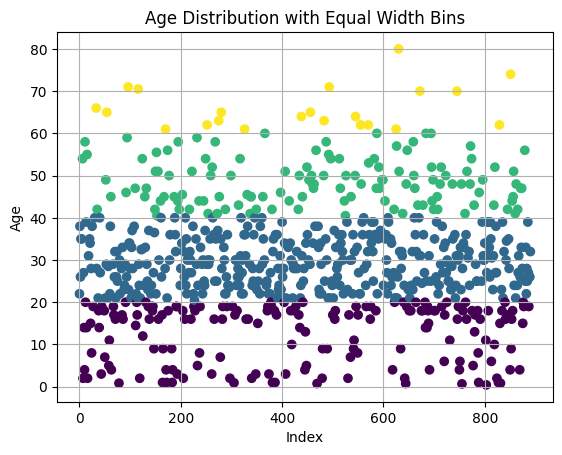

In [23]:
#Scatter Plot
plt.figure()
plt.scatter(data.index, data["Age"], c=data["age_equal_width"].cat.codes)
plt.title("Age Distribution with Equal Width Bins")
plt.xlabel("Index")
plt.ylabel("Age")
plt.grid(True)
plt.show()

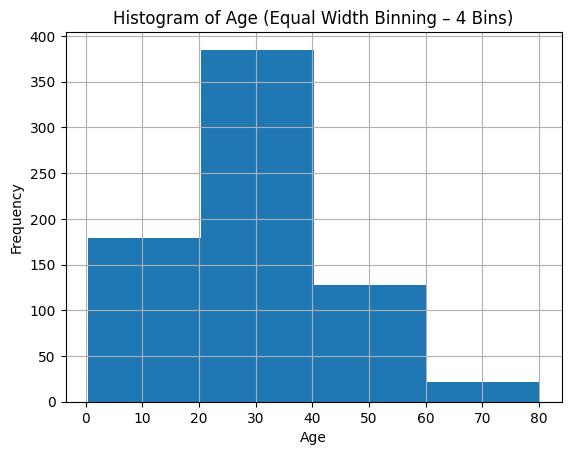

In [24]:
#Histogram
plt.figure()
plt.hist(data["Age"], bins=4)
plt.title("Histogram of Age (Equal Width Binning – 4 Bins)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

**Equal Depth / Equal Frequency Binning (Age)**

In [25]:
#4 equal frequency bins
data["age_equal_depth"] = pd.qcut(data["Age"], q=4)
data[["Age", "age_equal_depth"]].head()

,Age,age_equal_depth
0,22.0,"(20.125, 28.0]"
1,38.0,"(28.0, 38.0]"
2,26.0,"(20.125, 28.0]"
3,35.0,"(28.0, 38.0]"
4,35.0,"(28.0, 38.0]"


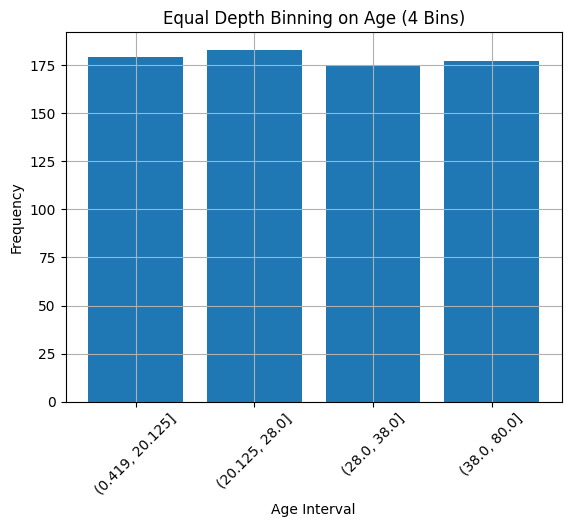

In [26]:
#Barchart
age_depth_counts = data["age_equal_depth"].value_counts().sort_index()

plt.figure()
plt.bar(age_depth_counts.index.astype(str), age_depth_counts.values)
plt.title("Equal Depth Binning on Age (4 Bins)")
plt.xlabel("Age Interval")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

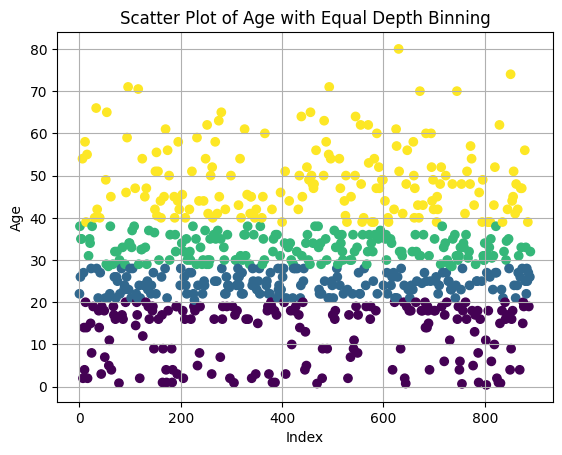

In [27]:
#Scatter Plot
plt.figure()
plt.scatter(data.index, data["Age"], c=data["age_equal_depth"].cat.codes)
plt.title("Scatter Plot of Age with Equal Depth Binning")
plt.xlabel("Index")
plt.ylabel("Age")
plt.grid(True)
plt.show()

**Quantile Binning**

In [28]:
#quartile bins explicitly
data["age_quantile_bin"] = pd.qcut(data["Age"], q=[0,0.25,0.50,0.75,1.0])
data[["Age", "age_quantile_bin"]].head()

,Age,age_quantile_bin
0,22.0,"(20.125, 28.0]"
1,38.0,"(28.0, 38.0]"
2,26.0,"(20.125, 28.0]"
3,35.0,"(28.0, 38.0]"
4,35.0,"(28.0, 38.0]"


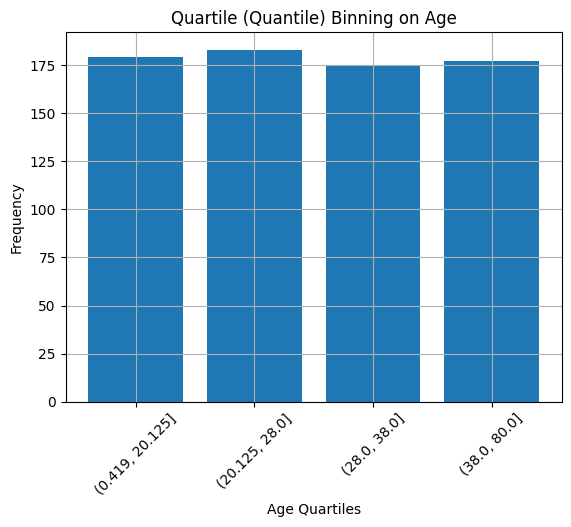

In [29]:
quartile_counts = data["age_quantile_bin"].value_counts().sort_index()

plt.figure()
plt.bar(quartile_counts.index.astype(str), quartile_counts.values)
plt.title("Quartile (Quantile) Binning on Age")
plt.xlabel("Age Quartiles")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

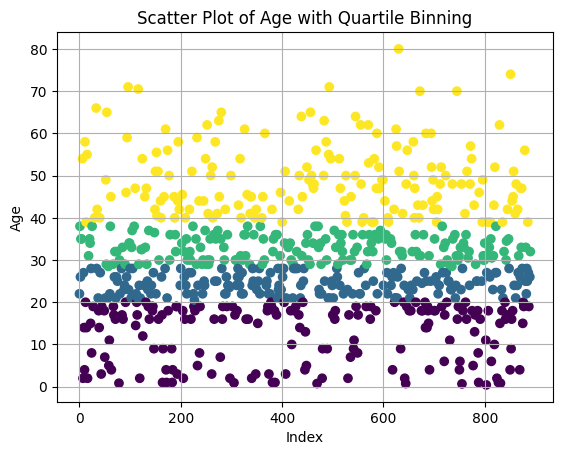

In [30]:
plt.figure()
plt.scatter(
    data.index,
    data["Age"],
    c=data["age_quantile_bin"].cat.codes
)
plt.title("Scatter Plot of Age with Quartile Binning")
plt.xlabel("Index")
plt.ylabel("Age")
plt.grid(True)
plt.show()

**Equal Frequency Binning on Fare**

In [31]:
data["fare_equal_depth"] = pd.qcut(data["Fare"], q=4)
data[["Fare", "fare_equal_depth"]].head()

,Fare,fare_equal_depth
0,7.2500,"(-0.001, 7.91]"
1,71.2833,"(31.0, 512.329]"
2,7.9250,"(7.91, 14.454]"
3,53.1000,"(31.0, 512.329]"
4,8.0500,"(7.91, 14.454]"


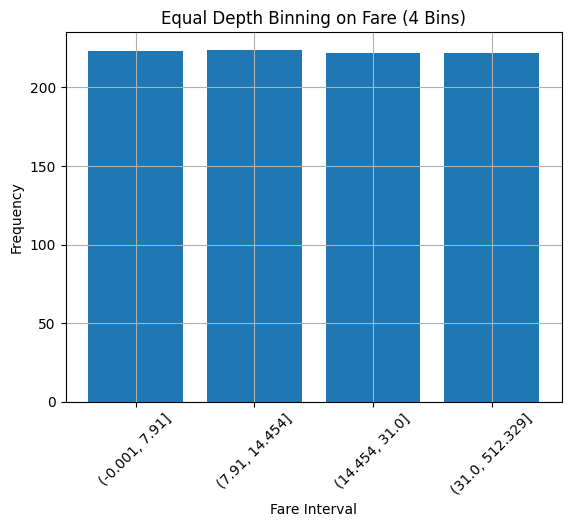

In [32]:
#Bar Chart
fare_bin_counts = data["fare_equal_depth"].value_counts().sort_index()

plt.figure()
plt.bar(fare_bin_counts.index.astype(str), fare_bin_counts.values)
plt.title("Equal Depth Binning on Fare (4 Bins)")
plt.xlabel("Fare Interval")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

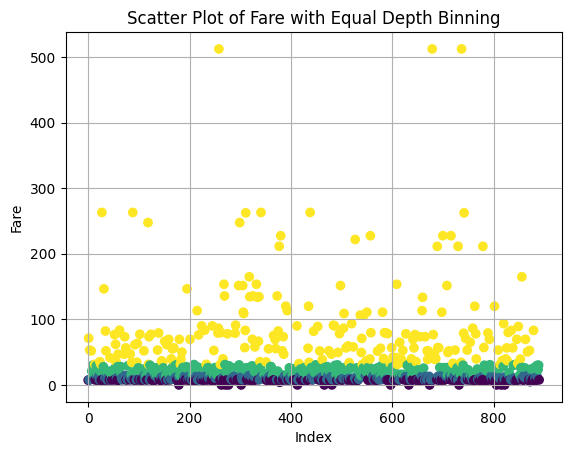

In [33]:
#Scatter Plot
plt.figure()
plt.scatter(
    data.index,
    data["Fare"],
    c=data["fare_equal_depth"].cat.codes
)
plt.title("Scatter Plot of Fare with Equal Depth Binning")
plt.xlabel("Index")
plt.ylabel("Fare")
plt.grid(True)
plt.show()

**Smoothing by Bin Mean (Age)**

In [34]:
bins = data["age_equal_depth"]

data["age_smooth_mean"] = bins.map(data.groupby(bins)["Age"].mean())
data[["Age", "age_equal_depth", "age_smooth_mean"]].head()

/tmp/ipython-input-3170011426.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data["age_smooth_mean"] = bins.map(data.groupby(bins)["Age"].mean())


,Age,age_equal_depth,age_smooth_mean
0,22.0,"(20.125, 28.0]",24.374317
1,38.0,"(28.0, 38.0]",32.880000
2,26.0,"(20.125, 28.0]",24.374317
3,35.0,"(28.0, 38.0]",32.880000
4,35.0,"(28.0, 38.0]",32.880000


/tmp/ipython-input-618511476.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = data.groupby("age_equal_depth")["Age"].mean()


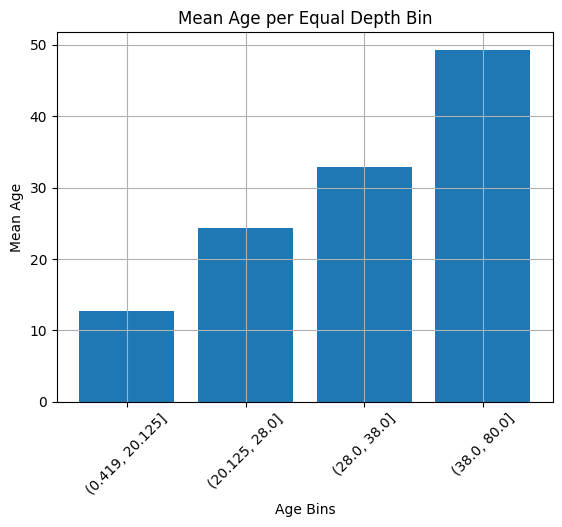

In [35]:
#Bar Chart
bin_means = data.groupby("age_equal_depth")["Age"].mean()

plt.figure()
plt.bar(bin_means.index.astype(str), bin_means.values)
plt.title("Mean Age per Equal Depth Bin")
plt.xlabel("Age Bins")
plt.ylabel("Mean Age")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

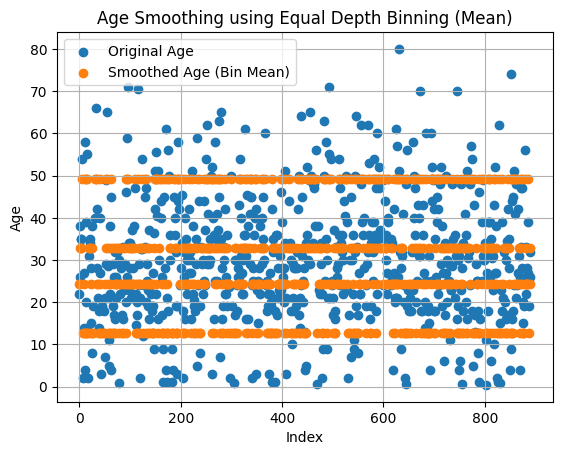

In [36]:
#Scatter Plot
plt.figure()
plt.scatter(data.index, data["Age"], label="Original Age")
plt.scatter(data.index, data["age_smooth_mean"], label="Smoothed Age (Bin Mean)")
plt.title("Age Smoothing using Equal Depth Binning (Mean)")
plt.xlabel("Index")
plt.ylabel("Age")
plt.legend()
plt.grid(True)
plt.show()

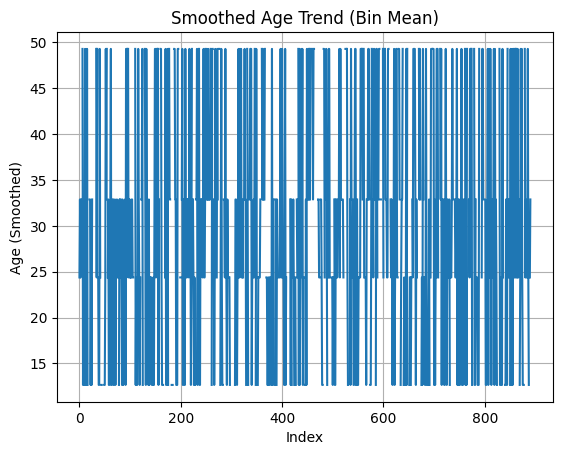

In [37]:
#Line Plot
plt.figure()
plt.plot(data.index, data["age_smooth_mean"])
plt.title("Smoothed Age Trend (Bin Mean)")
plt.xlabel("Index")
plt.ylabel("Age (Smoothed)")
plt.grid(True)
plt.show()

**Smoothing by Bin Median (Age)**

In [38]:
data["age_smooth_median"] = bins.map(data.groupby(bins)["Age"].median())
data[["Age", "age_equal_depth", "age_smooth_median"]].head()

/tmp/ipython-input-2004241922.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data["age_smooth_median"] = bins.map(data.groupby(bins)["Age"].median())


,Age,age_equal_depth,age_smooth_median
0,22.0,"(20.125, 28.0]",24.0
1,38.0,"(28.0, 38.0]",33.0
2,26.0,"(20.125, 28.0]",24.0
3,35.0,"(28.0, 38.0]",33.0
4,35.0,"(28.0, 38.0]",33.0


/tmp/ipython-input-919023773.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_medians = data.groupby("age_equal_depth")["Age"].median()


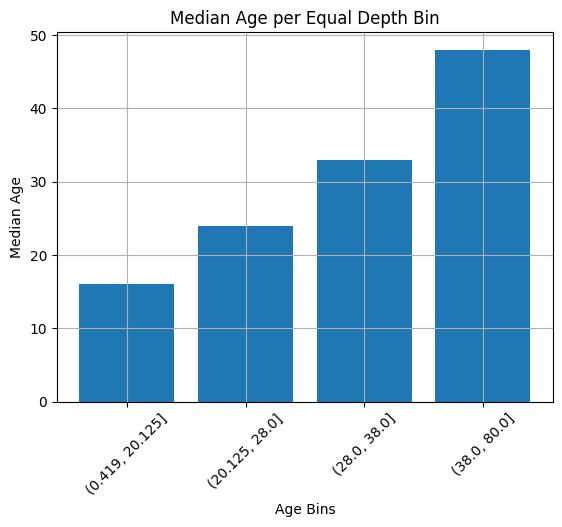

In [39]:
bin_medians = data.groupby("age_equal_depth")["Age"].median()

plt.figure()
plt.bar(bin_medians.index.astype(str), bin_medians.values)
plt.title("Median Age per Equal Depth Bin")
plt.xlabel("Age Bins")
plt.ylabel("Median Age")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

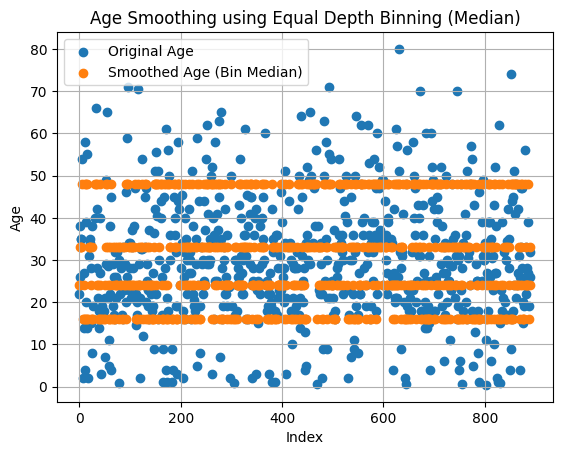

In [40]:
plt.figure()
plt.scatter(data.index, data["Age"], label="Original Age")
plt.scatter(
    data.index,
    data["age_smooth_median"],
    label="Smoothed Age (Bin Median)"
)
plt.title("Age Smoothing using Equal Depth Binning (Median)")
plt.xlabel("Index")
plt.ylabel("Age")
plt.legend()
plt.grid(True)
plt.show()

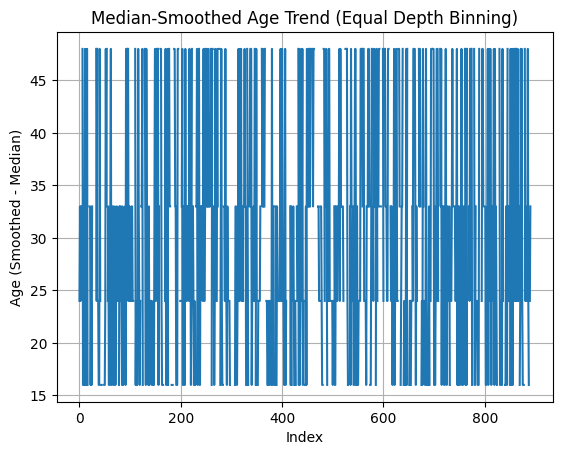

In [41]:
plt.figure()
plt.plot(data.index, data["age_smooth_median"])
plt.title("Median-Smoothed Age Trend (Equal Depth Binning)")
plt.xlabel("Index")
plt.ylabel("Age (Smoothed - Median)")
plt.grid(True)
plt.show()

**Smoothing by Bin Boundary (Age)**

In [42]:
intervals = bins.cat.categories

def smooth_boundary(value, interval):
    lower, upper = interval.left, interval.right
    return lower if abs(value-lower) < abs(value-upper) else upper

data["age_smooth_boundary"] = [
    smooth_boundary(data.loc[i, "Age"], intervals[bins.cat.codes[i]])
    for i in range(len(data))
]

data[["Age", "age_equal_depth", "age_smooth_boundary"]].head()

,Age,age_equal_depth,age_smooth_boundary
0,22.0,"(20.125, 28.0]",20.125
1,38.0,"(28.0, 38.0]",38.000
2,26.0,"(20.125, 28.0]",28.000
3,35.0,"(28.0, 38.0]",38.000
4,35.0,"(28.0, 38.0]",38.000


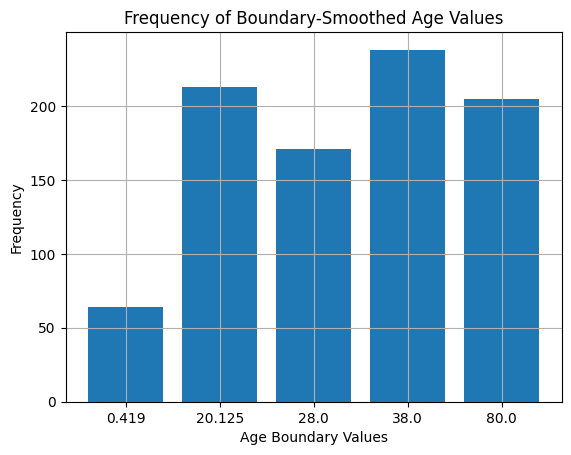

In [43]:
boundary_counts = data["age_smooth_boundary"].value_counts().sort_index()

plt.figure()
plt.bar(boundary_counts.index.astype(str), boundary_counts.values)
plt.title("Frequency of Boundary-Smoothed Age Values")
plt.xlabel("Age Boundary Values")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

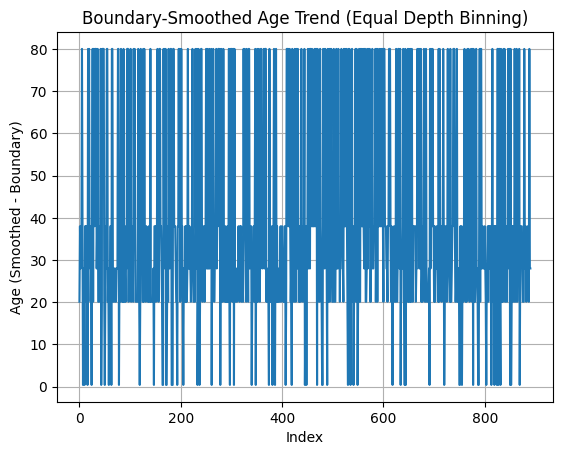

In [44]:
plt.figure()
plt.plot(data.index, data["age_smooth_boundary"])
plt.title("Boundary-Smoothed Age Trend (Equal Depth Binning)")
plt.xlabel("Index")
plt.ylabel("Age (Smoothed - Boundary)")
plt.grid(True)
plt.show()

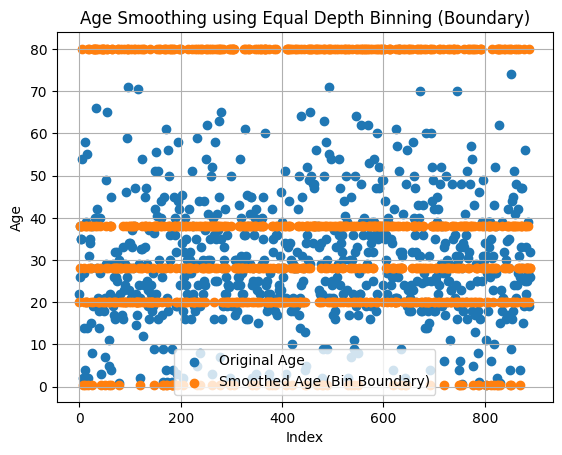

In [45]:
plt.figure()
plt.scatter(data.index, data["Age"], label="Original Age")
plt.scatter(
    data.index,
    data["age_smooth_boundary"],
    label="Smoothed Age (Bin Boundary)"
)
plt.title("Age Smoothing using Equal Depth Binning (Boundary)")
plt.xlabel("Index")
plt.ylabel("Age")
plt.legend()
plt.grid(True)
plt.show()

**You can perform various visualizations using individual columns as well as advanced visualizations.**